This is a simple notebook that gives a demonstration of k-means, DBSCAN and GMM.  
It accompanies Chapter 7 of the book (1 of 4) and also shows how different figures were made.  
Copyright: Viviana Acquaviva (2023); see also other credits below, in particular Jake Vanderplas' [excellent notebooks](https://jakevdp.github.io/PythonDataScienceHandbook/05.00-machine-learning.html).  
Modifications by Aaron Romanowsky.  
License: [BSD-3-clause](https://opensource.org/license/bsd-3-clause/)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn import metrics

In [2]:
# %pip install mlxtend --upgrade # I had to run this to make plot_decision_regions work; provoked major updates in pandas, etc.
# %pip install numexpr --upgrade
# %pip install -U scikit-learn pyarrow

In [3]:
from mlxtend.plotting import plot_decision_regions

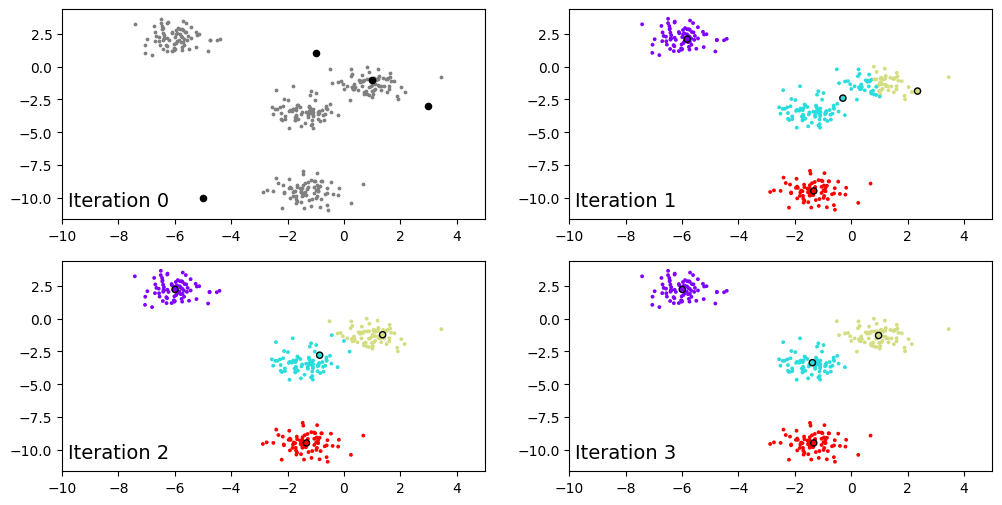

In [4]:
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.6, random_state=2)

fig1 = plt.figure(figsize=(12,6))

start = np.array([[-1,1],[1,-1],[3,-3],[-5,-10]]) #initial points (fixed for reproducibility; Fig 7.3)

plt.subplot(2,2,1)
plt.scatter(X[:, 0], X[:, 1], s =3, c ='gray') # plot original points
plt.scatter(start[:,0],start[:,1], s = 20, c = 'k', label = 'Iteration 0');
plt.xlim(-10,5);
plt.annotate('Iteration 0', xy=(77, 20), xycoords='axes points',
            size=14, ha='right', va='top')

for i in range(1,4):
    plt.subplot(2,2,i+1)
    kmeans = KMeans(n_clusters=4, max_iter = i, init = start, n_init=1)
    kmeans.fit(X)
    y_kmeans = kmeans.predict(X)
    centroids = kmeans.cluster_centers_
    plt.scatter(X[:, 0], X[:, 1], s = 3, c = y_kmeans, cmap = 'rainbow') # plot original points
    plt.scatter(centroids[:, 0], centroids[:, 1], s=20, \
                edgecolor = 'k', label = 'Iteration'+str(i), c = [0,1,2,3],cmap = 'rainbow');
    plt.xlim(-10,5);
    plt.annotate('Iteration '+str(i), xy=(77, 20), xycoords='axes points',
            size=14, ha='right', va='top')


### First slightly tricky example: overlapping blobs of different size/density.

In [5]:
X1b, y1b = make_blobs(n_samples=200, centers=[(1.25,1)],
                       cluster_std=0.2, random_state=1)

X2b, y2b = make_blobs(n_samples=400, centers=[(0,1)],
                       cluster_std=0.5, random_state=2)

X3b, y3b = make_blobs(n_samples=200, centers=[(-1.25,1)],
                       cluster_std=0.2, random_state=3)

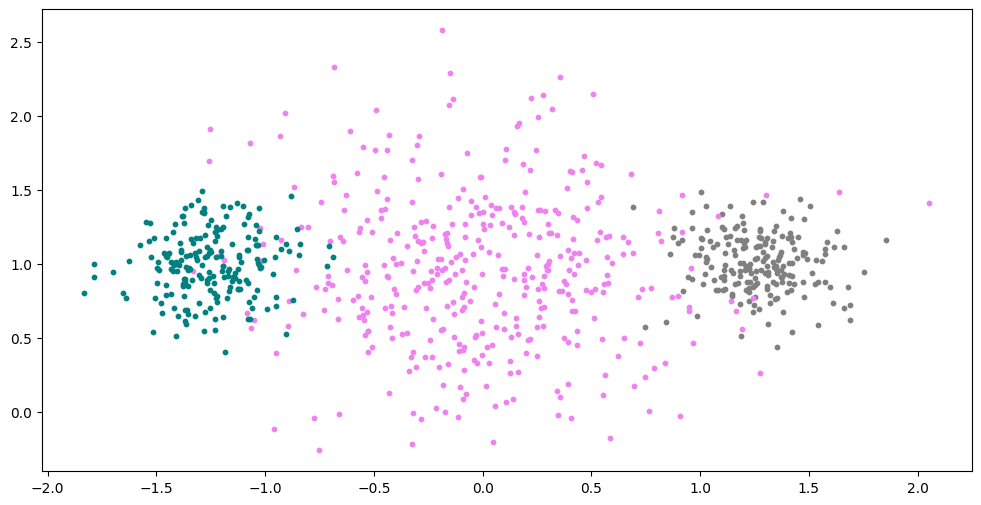

In [6]:
fig2 = plt.figure(figsize=(12,6))

plt.scatter(X1b[:, 0], X1b[:, 1], s =10, c ='gray') # plot original points

plt.scatter(X2b[:, 0], X2b[:, 1], s =10, c ='violet') # plot original points

plt.scatter(X3b[:, 0], X3b[:, 1], s =10, c ='teal') # plot original points

Combine clusters in single data set:

In [7]:
Xb = np.vstack([X1b,X2b,X3b])

Fixing the random seed generates consistent predictions (the predictions of the cluster assignments are usually consistent, but which cluster is predicted as 0, which as 1, which as 2 would otherwise vary.)

In [8]:
kmeans = KMeans(n_clusters=3, n_init = 10, random_state=30) #predicts 0,1,2
kmeans.fit(Xb)
yb_kmeans = kmeans.predict(Xb)
centersb = kmeans.cluster_centers_
yb_kmeans

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 1,
       0, 2, 2, 0, 1, 2, 2, 2, 1, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 1, 2,
       2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 0, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0,

Create vector of labels with the same convention for verification.

In [9]:
yb = np.concatenate([np.zeros(len(y1b)),np.zeros(len(y2b))+1,np.zeros(len(y3b))+2])

Now we can compare the cluster assignments from the k means algorithm to the original ones.

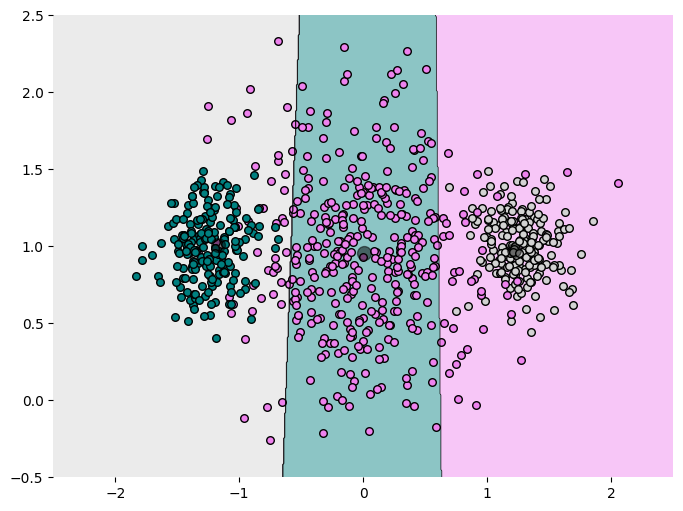

In [10]:
fig3 = plt.figure(figsize=(8,6))
model = KMeans(n_clusters=3, n_init = 10, random_state=30) #predicts 0,1,2
model.fit(Xb)
plot_decision_regions(Xb, yb.astype(int), clf = model, legend=0, markers = '...', colors = 'lightgray,violet,teal')
plt.scatter(X1b[:,0],X1b[:,1], s = 30, c = 'lightgray',edgecolors='k')
plt.scatter(X2b[:,0],X2b[:,1], s = 30, c = 'violet', edgecolors='k')
plt.scatter(X3b[:,0],X3b[:,1],s = 30, c = 'teal', edgecolors='k')
plt.scatter(centersb[:, 0], centersb[:, 1], c='black', s=100, alpha=0.5);

plt.xlim(-2.5,2.5)
plt.ylim(-0.5,2.5);
# plt.savefig('ClustersBad.pdf', dpi = 300)

### Now we move on to a different distribution (smiley face).

Generate points for the smiley face distribution:

In [45]:
from math import pi, cos, sin
from random import random

def point(h, k, r):
    theta = random() * 2 * pi
    return h + cos(theta) * r, k + sin(theta) * r + 0.2*random()

xy = [point(1,2,1) for _ in range(100)]

type(xy)

list

In [12]:
X1, y1 = make_blobs(n_samples=10, centers=[(0.5,2.5)],
                       cluster_std=0.05, random_state=1)

X2, y2 = make_blobs(n_samples=10, centers=[(1.5,2.5)],
                       cluster_std=0.05, random_state=2)

X3, y3 = make_blobs(n_samples=10, centers=[(1,1.7)],
                       cluster_std=0.05, random_state=2)

In [13]:
X3_stretch = np.array([X3[:,0]*3, X3[:,1]]) #make the mouth :) 

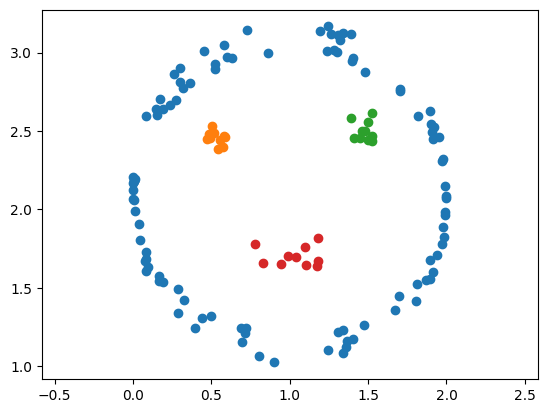

In [14]:
fig4 = plt.figure()

plt.axes().set_aspect('equal', 'datalim')
plt.scatter(*zip(*xy))
plt.scatter(X1[:,0],X1[:,1])
plt.scatter(X2[:,0],X2[:,1])
plt.scatter(X3_stretch.T[:,0]-1.9,X3_stretch.T[:,1])

plt.show()

Finally, put together the four sets of points in the figure to create the data set as a single array:


In [15]:
X = np.vstack([xy,X1,X2,np.array([X3_stretch.T[:,0]-1.9,X3_stretch.T[:,1]]).T])

### Let's see how k-means clusters these points.

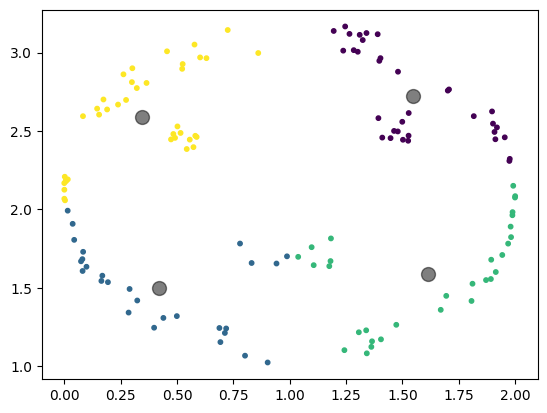

In [16]:
kmeans = KMeans(n_clusters=4, n_init = 10, random_state=32) #We can also change the number of clusters
kmeans.fit(X)
y_kmeans = kmeans.predict(X)
centers = kmeans.cluster_centers_

fig5 = plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=10, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=100, alpha=0.5);

Create vector with true labels (color the points):

In [17]:
y = np.concatenate([np.zeros(len(xy)), np.zeros(len(y1))+1,np.zeros(len(y2))+2,np.zeros(len(y3))+3])

Finally, compare the clustering assignments of k means (background color) to the true labels:

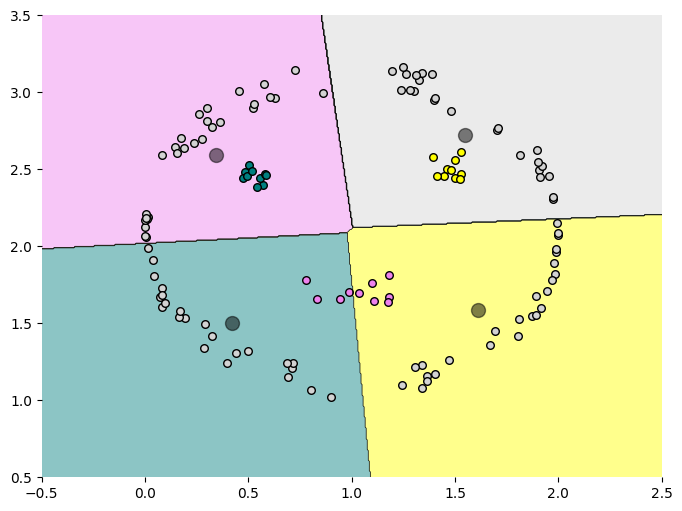

In [18]:
fig6 = plt.figure(figsize=(8,6))
plot_decision_regions(X, y.astype(int), clf = kmeans, legend=0, markers = '.', colors = 'lightgray,teal,yellow,violet')
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=100, alpha=0.5);
plt.scatter(*zip(*xy), s = 30, c = 'lightgray', edgecolors='k')
plt.scatter(X1[:,0],X1[:,1], s = 30, c = 'teal',edgecolors='k')
plt.scatter(X2[:,0],X2[:,1], s = 30, c = 'yellow', edgecolors='k')
plt.scatter(X3_stretch.T[:,0]-1.9,X3_stretch.T[:,1],s = 30, c = 'violet', edgecolors='k')
plt.xlim(-0.5,2.5);
plt.ylim(0.5,3.5);
#plt.savefig('ClustersBad2.pdf', dpi = 300)

#### The Elbow curve can be used to infer the number of clusters.

This is for the smiley face...

In [19]:
inertias = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, n_init = 10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

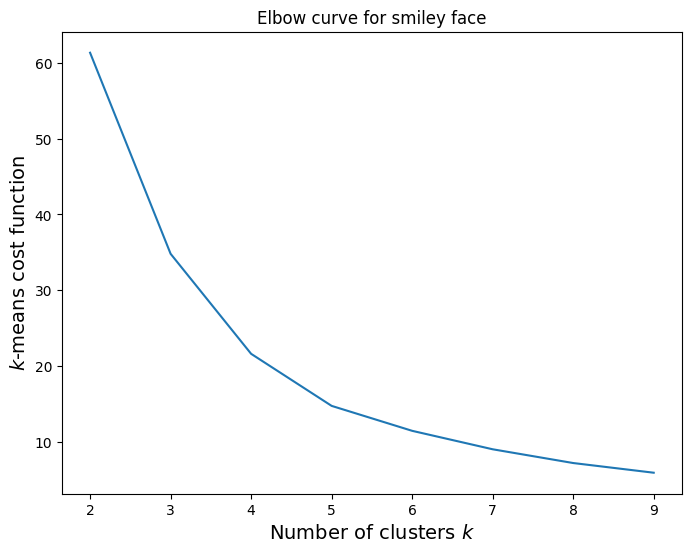

In [20]:
fig7 = plt.figure(figsize=(8, 6))
plt.plot(range(2, 10), inertias)
plt.title('Elbow curve for smiley face');
plt.xlabel('Number of clusters $k$', fontsize = 14);
plt.ylabel('$k$-means cost function', fontsize = 14);


... and this is for the blobs.

In [21]:
inertiasb = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, n_init = 10)
    kmeans.fit(Xb)
    inertiasb.append(kmeans.inertia_)

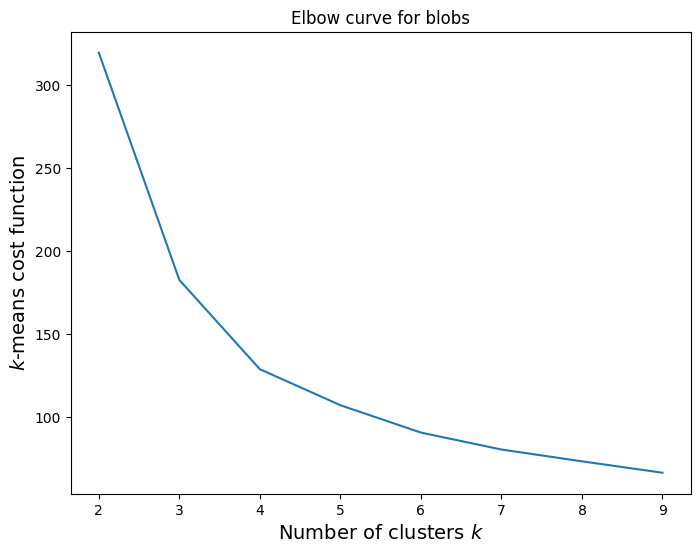

In [22]:
fig8 = plt.figure(figsize=(8, 6))
plt.plot(range(2, 10), inertiasb)
#plt.grid(True)
plt.title('Elbow curve for blobs');
plt.xlabel('Number of clusters $k$', fontsize = 14);
plt.ylabel('$k$-means cost function', fontsize = 14);


In both cases, n = 4 is the preferred choice (note that for the blobs, this is incorrect, and for the smiley face, this is correct but mostly by chance, as the distribution is not one that k-means can handle correctly).

### Silhouette score

The silhouette score is another metric used to evaluate the success of a clustering method and pick a number of clusters. Higher values correspond to better-defined clustering schemes.

In [23]:
from sklearn.metrics import silhouette_samples, silhouette_score

C:\Users\Simon Seo\AppData\Local\Temp\ipykernel_30552\1610941701.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X[:, 0], X[:, 1], c=colors, s=40, cmap='flare', edgecolor='k');
C:\Users\Simon Seo\AppData\Local\Temp\ipykernel_30552\1610941701.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X[:, 0], X[:, 1], c=colors, s=40, cmap='flare', edgecolor='k');
C:\Users\Simon Seo\AppData\Local\Temp\ipykernel_30552\1610941701.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X[:, 0], X[:, 1], c=colors, s=40, cmap='flare', edgecolor='k');
C:\Users\Simon Seo\AppData\Local\Temp\ipykernel_30552\1610941701.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X[:, 0], X[:, 1], c=colors, s=40, cmap='flare', edgecolor='k');


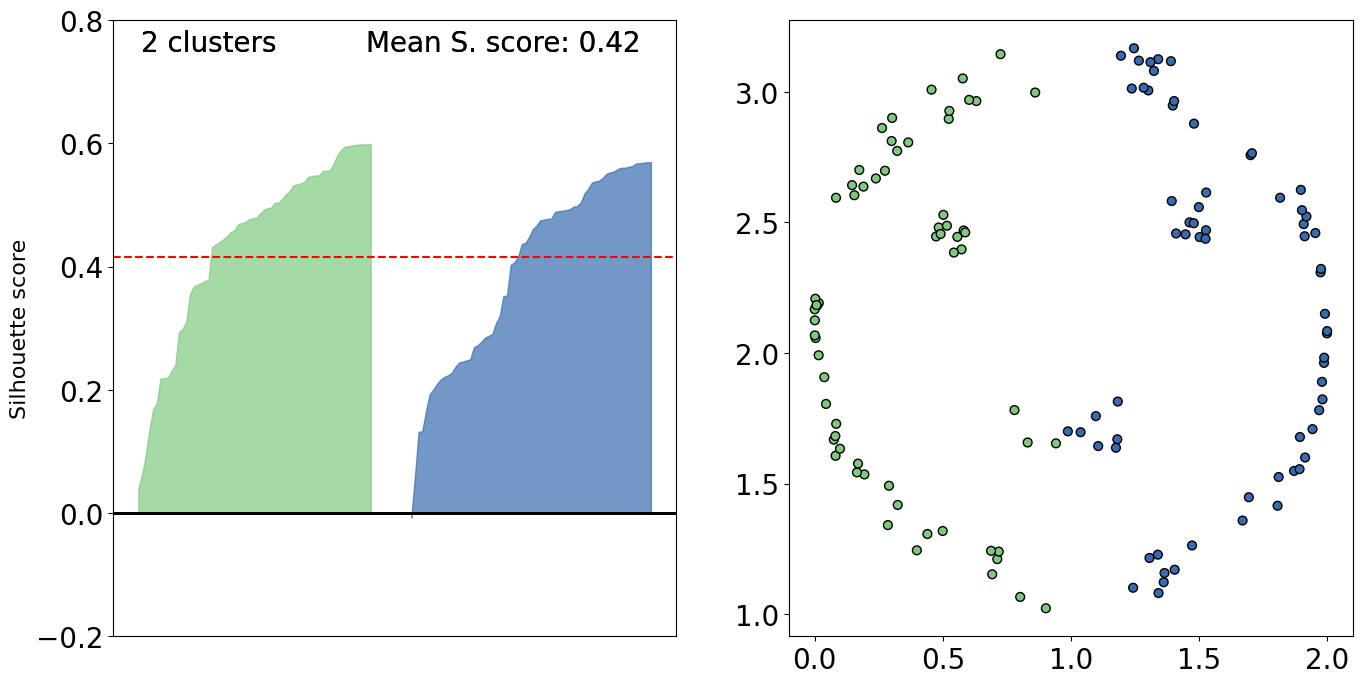

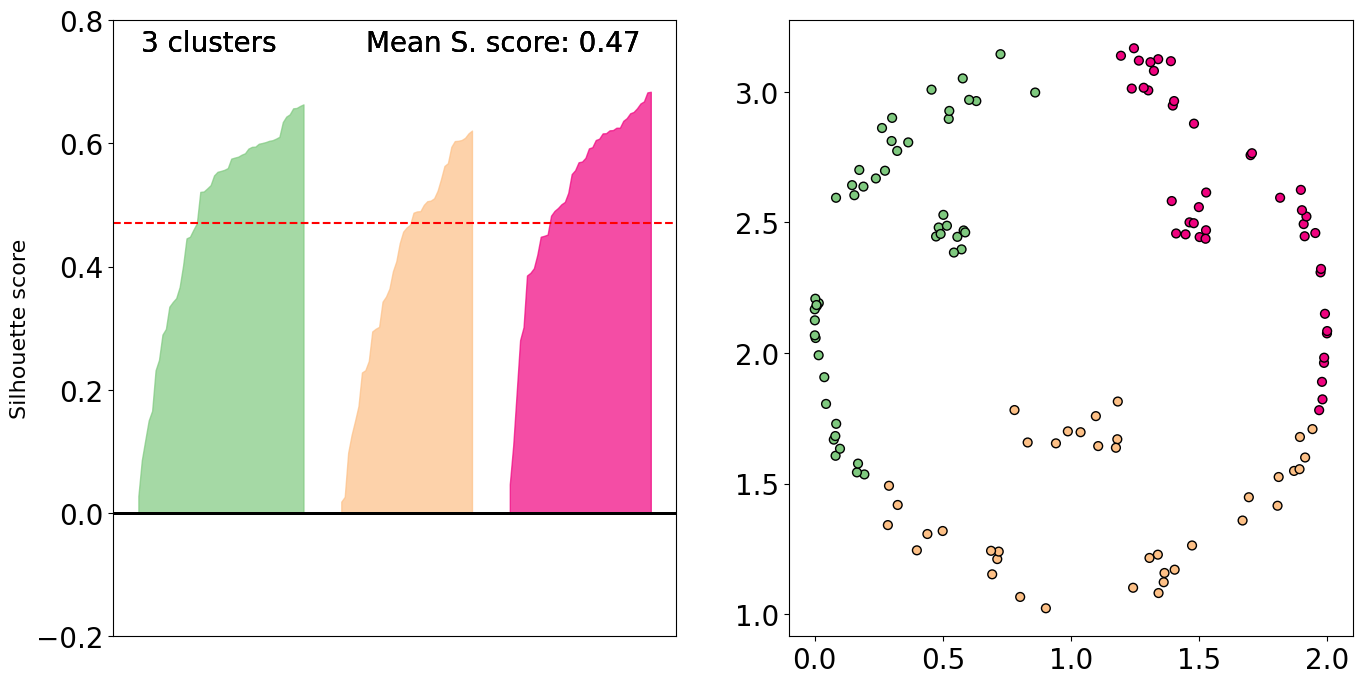

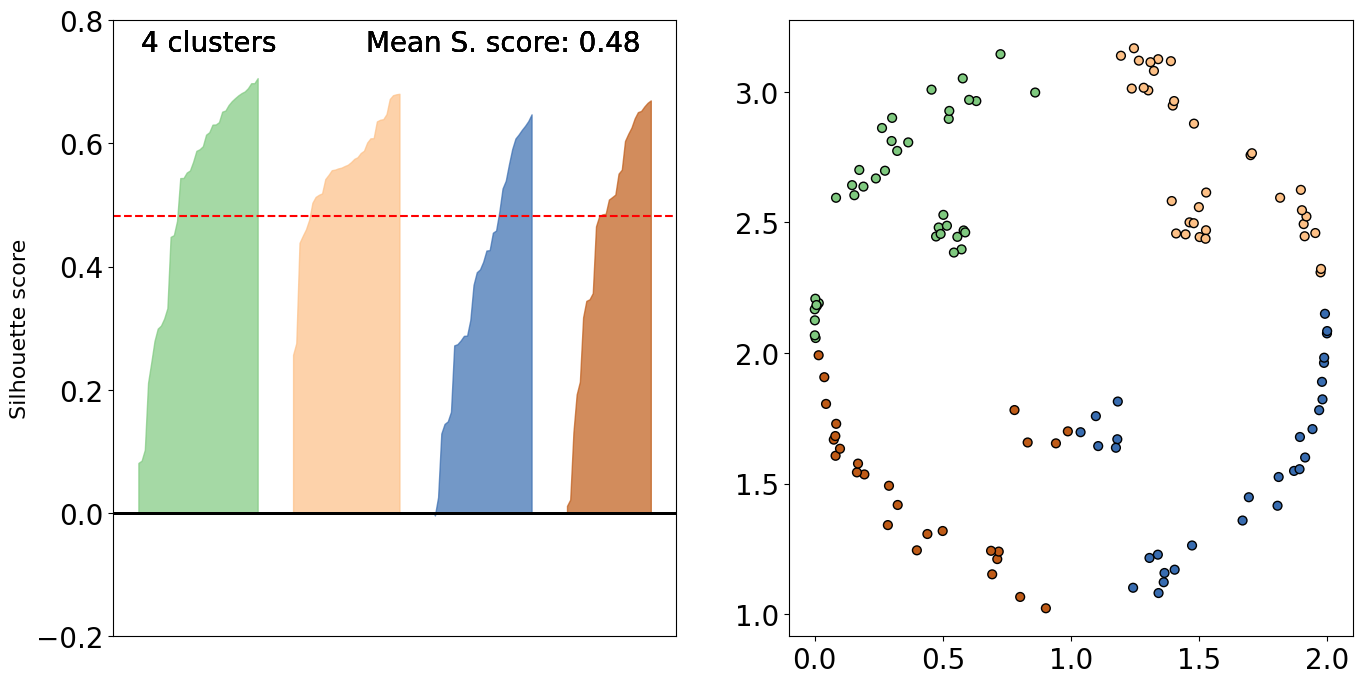

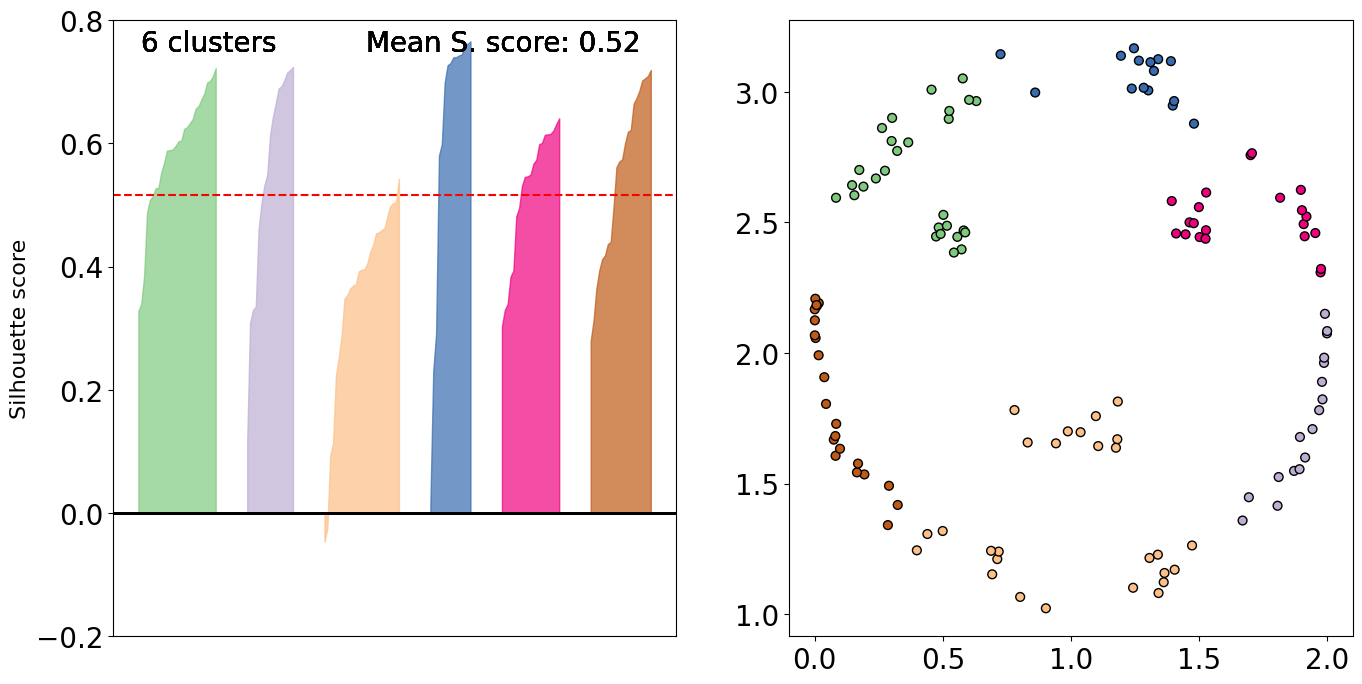

In [24]:
#Smiley face

n_clusters = [2,3,4,6]

for n in n_clusters:
    
    model = KMeans(n_clusters = n, n_init = 10, random_state=10)

    model.fit(X)

    y_kmeans = model.predict(X)

    silhouette_scores = silhouette_samples(X, y_kmeans)

    xlower = 10

    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    
    ax = axs[1]
    colors = plt.cm.Accent(y_kmeans.astype(float)/n)
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=40, cmap='flare', edgecolor='k');
    ax.tick_params(axis='both', which='both', labelsize=20);

    ax = axs[0]

    for i in np.unique(y_kmeans):
        ind = y_kmeans==i
        silh = np.sort(silhouette_scores[ind])
        size_cluster_i = silh.shape[0]
        xupper = xlower + size_cluster_i
        color = plt.cm.Accent(float(i)/model.n_clusters)
        ax.fill_between(np.arange(xlower, xupper), 0, silh, facecolor=color, edgecolor=color, alpha=0.7)
        ax.axhline(y=0, c='k', lw=2)
        ax.text(0.05, 0.95, '%0.0f clusters'%n, transform=ax.transAxes, fontsize=20)
        ax.text(0.45, 0.95, 'Mean S. score: %0.2f'%np.mean(silhouette_scores), transform=ax.transAxes, fontsize=20)
        xlower = xupper + 10
        ax.set_ylabel('Silhouette score', fontsize=16)
        ax.set_ylim(-0.2,0.8)
        
    ax.axhline(y=np.mean(silhouette_scores), color="red", linestyle="--")
    ax.tick_params(axis='both', which='both', labelsize=20);
    ax.set_xticks([]);
#    figname = 'SilhouetteSmiley'+str(n)+'.pdf'
#    plt.savefig(figname, dpi = 300)

In the example above, the silhouette score points to 4 clusters, but keep in mind that any of these methods (elbow method, silhouette score) only makes sense if the hypothesis that clustered can be correctly identified by k-means (in other words, are convex, globular, and similar in shape and density). This is not the case here!

C:\Users\Simon Seo\AppData\Local\Temp\ipykernel_30552\343476603.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(Xb[:, 0], Xb[:, 1], c=colors, s=40, cmap='flare', edgecolor='k');
C:\Users\Simon Seo\AppData\Local\Temp\ipykernel_30552\343476603.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(Xb[:, 0], Xb[:, 1], c=colors, s=40, cmap='flare', edgecolor='k');
C:\Users\Simon Seo\AppData\Local\Temp\ipykernel_30552\343476603.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(Xb[:, 0], Xb[:, 1], c=colors, s=40, cmap='flare', edgecolor='k');
C:\Users\Simon Seo\AppData\Local\Temp\ipykernel_30552\343476603.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(Xb[:, 0], Xb[:, 1], c=colors, s=40, cmap='flare', edgecolor='k');


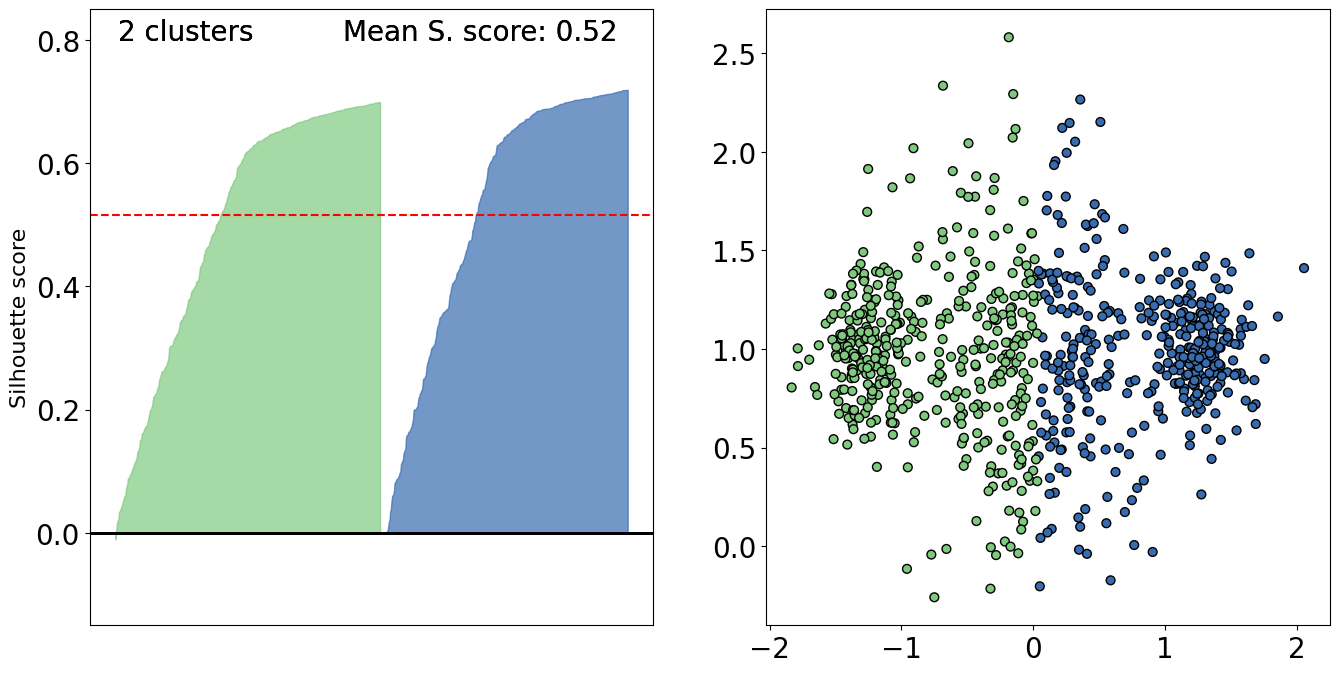

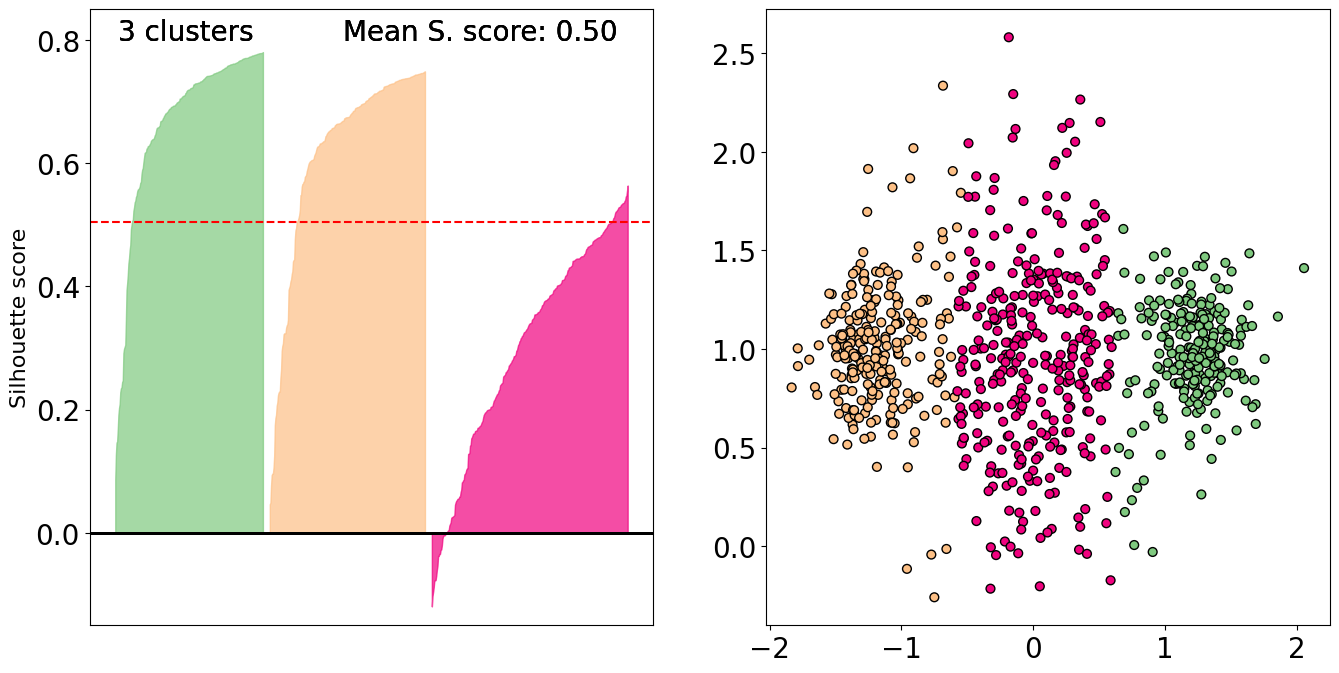

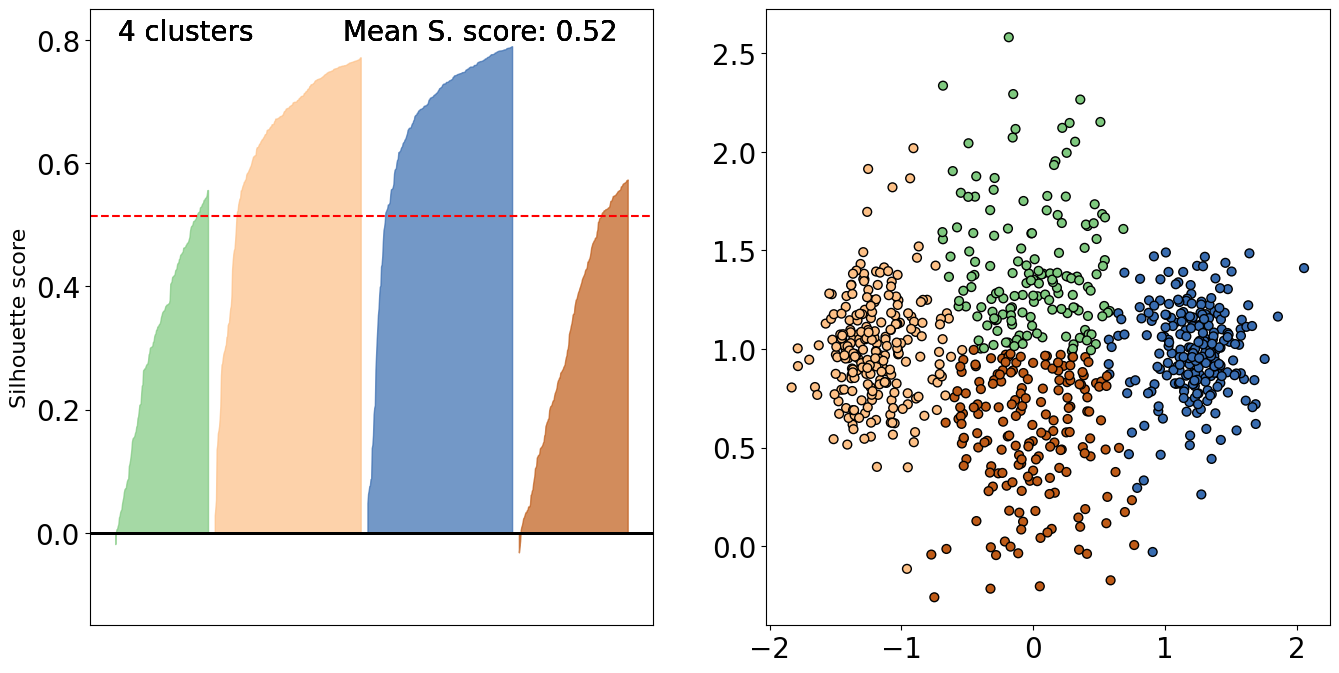

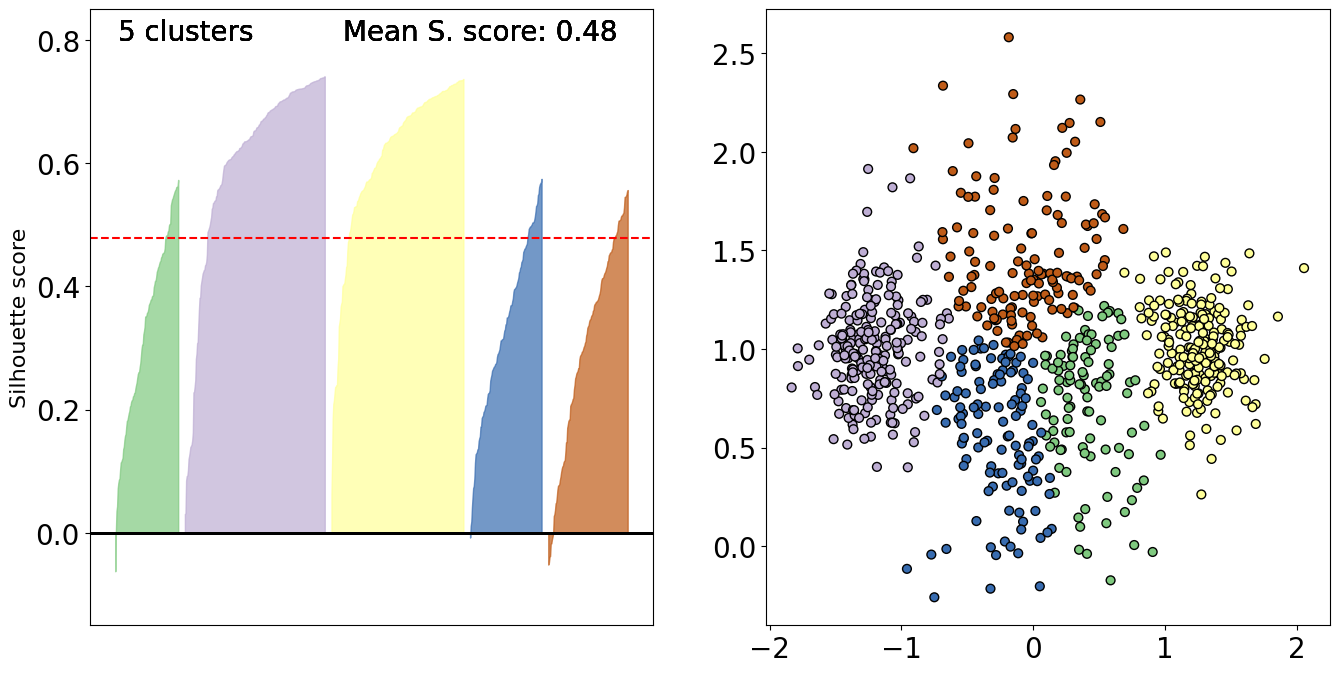

In [25]:
#Blobs 

n_clusters = np.arange(2, 6)

for n in n_clusters:
    
    model = KMeans(n_clusters = n, n_init = 10, random_state = 10)

    model.fit(Xb)

    y_kmeans = model.predict(Xb)
    
    silhouette_scores = silhouette_samples(Xb, y_kmeans)

    xlower = 10

    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    
    ax = axs[1]
    colors = plt.cm.Accent(y_kmeans.astype(float)/n)
    ax.scatter(Xb[:, 0], Xb[:, 1], c=colors, s=40, cmap='flare', edgecolor='k');
    ax.tick_params(axis='both', which='both', labelsize=20);

    ax = axs[0]

    for i in np.unique(y_kmeans):
        ind = y_kmeans==i
        silh = np.sort(silhouette_scores[ind])
        size_cluster_i = silh.shape[0]
        xupper = xlower + size_cluster_i
        color = plt.cm.Accent(float(i)/model.n_clusters)
        ax.fill_between(np.arange(xlower, xupper), 0, silh, facecolor=color, edgecolor=color, alpha=0.7)
        ax.axhline(y=0, c='k', lw=2)
        ax.text(0.05, 0.95, '%0.0f clusters'%n, transform=ax.transAxes, fontsize=20)
        ax.text(0.45, 0.95, 'Mean S. score: %0.2f'%np.mean(silhouette_scores), transform=ax.transAxes, fontsize=20)
        xlower = xupper + 10
        ax.set_ylabel('Silhouette score', fontsize=16)
        ax.set_ylim(-0.15,0.85)
        
    ax.axhline(y=np.mean(silhouette_scores), color="red", linestyle="--")
    ax.tick_params(axis='both', which='both', labelsize=20);
    ax.set_xticks([]);
#    figname = 'SilhouetteBlobs'+str(n)+'.pdf'
#    plt.savefig(figname, dpi = 300)

### We can now take a quick look at two density-based clustering methods, DBSCAN and OPTICS.

In [26]:
from sklearn.cluster import DBSCAN

#Code adapted from: https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html

From the sklearn docs:

The DBSCAN algorithm views clusters as areas of high density separated by areas of low density. Due to this rather generic view, clusters found by DBSCAN can be any shape, as opposed to k-means which assumes that clusters are convex shaped. The central component to the DBSCAN is the concept of core samples, which are samples that are in areas of high density. A cluster is therefore a set of core samples, each close to each other (measured by some distance measure) and a set of non-core samples that are close to a core sample (but are not themselves core samples). There are two parameters to the algorithm, min_samples and eps, which define formally what we mean when we say dense. Higher min_samples or lower eps indicate higher density necessary to form a cluster.

More formally, we define a core sample as being a sample in the dataset such that there exist min_samples other samples within a distance of eps, which are defined as neighbors of the core sample. This tells us that the core sample is in a dense area of the vector space. A cluster is a set of core samples that can be built by recursively taking a core sample, finding all of its neighbors that are core samples, finding all of their neighbors that are core samples, and so on. A cluster also has a set of non-core samples, which are samples that are neighbors of a core sample in the cluster but are not themselves core samples. Intuitively, these samples are on the fringes of a cluster.

Any core sample is part of a cluster, by definition. Any sample that is not a core sample, and is at least eps in distance from any core sample, is considered an outlier by the algorithm.

Estimated number of clusters: 6
Estimated number of noise points: 0


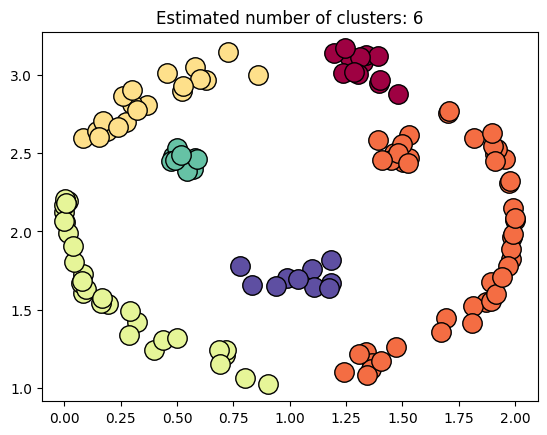

In [27]:
# #############################################################################
# Compute DBSCAN
db = DBSCAN(eps=0.25, min_samples=2).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print('Estimated number of clusters: %d' % n_clusters_)
print('Estimated number of noise points: %d' % n_noise_)

# #############################################################################

# Black removed and is used for noise instead.
unique_labels = set(labels)
colors = [plt.cm.Spectral(each)
          for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = (labels == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=14)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6)

plt.title('Estimated number of clusters: %d' % n_clusters_)
plt.show()

We can see how the clustering changes as we vary the distance parameter, eps:

Estimated number of clusters: 9
Estimated number of noise points: 0


<>:43: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:43: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
C:\Users\Simon Seo\AppData\Local\Temp\ipykernel_30552\2443706112.py:43: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.title('$\epsilon$ = %0.2f; estimated number of clusters: %d' % (eps, n_clusters_))


Estimated number of clusters: 6
Estimated number of noise points: 0
Estimated number of clusters: 4
Estimated number of noise points: 0
Estimated number of clusters: 3
Estimated number of noise points: 0


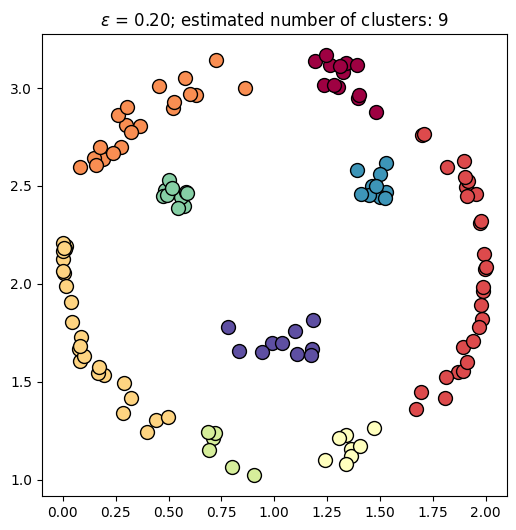

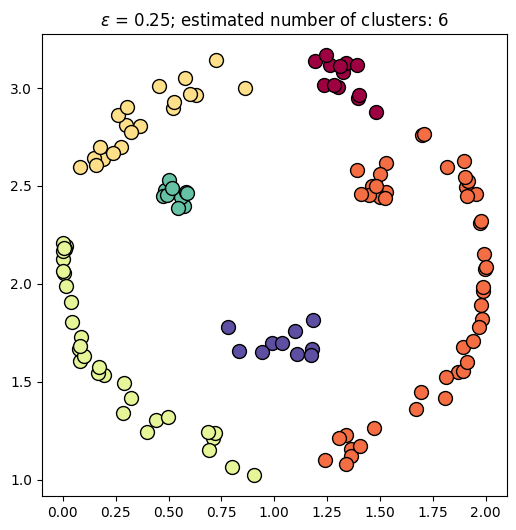

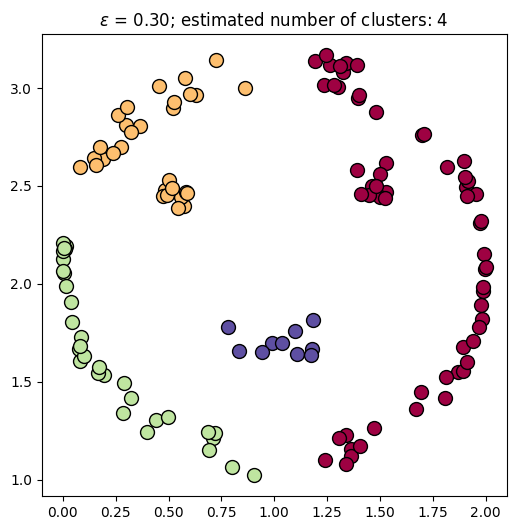

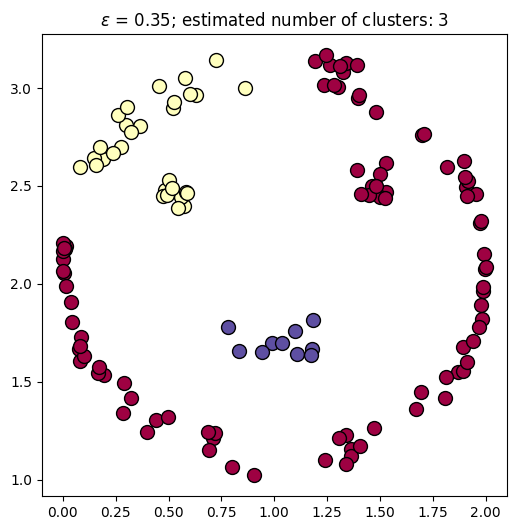

In [28]:
# #############################################################################
# Compute DBSCAN

for i,eps in enumerate([0.2, 0.25, 0.3, 0.35]):
    
    plt.figure(figsize = (6,6))
    
    db = DBSCAN(eps=eps, min_samples=2).fit(X)

    core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
    core_samples_mask[db.core_sample_indices_] = True
    labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)

    print('Estimated number of clusters: %d' % n_clusters_)
    print('Estimated number of noise points: %d' % n_noise_)

# #############################################################################


# Black removed and is used for noise instead.
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each)
          for each in np.linspace(0, 1, len(unique_labels))]
    for k, col in zip(unique_labels, colors):
        if k == -1:
        # Black used for noise.
            col = [0, 0, 0, 1]

        class_member_mask = (labels == k)

        xy = X[class_member_mask & core_samples_mask]
        plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=10)

        xy = X[class_member_mask & ~core_samples_mask]
        plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6)

    plt.title('$\epsilon$ = %0.2f; estimated number of clusters: %d' % (eps, n_clusters_))
    
    plt.savefig('DBSCAN_'+str(i)+'.pdf', dpi = 300)
    
    

### OPTICS

In [29]:
from sklearn.cluster import OPTICS

Partial source:
    
https://scikit-learn.org/stable/auto_examples/cluster/plot_optics.html

Estimated number of clusters: 11
Estimated number of noise points: 30


C:\Users\Simon Seo\AppData\Local\Temp\ipykernel_30552\2200483372.py:25: MatplotlibDeprecationWarning: Passing the marker parameter of scatter() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.scatter(Xk[:, 0], Xk[:, 1], 60, np.array([color,]),\


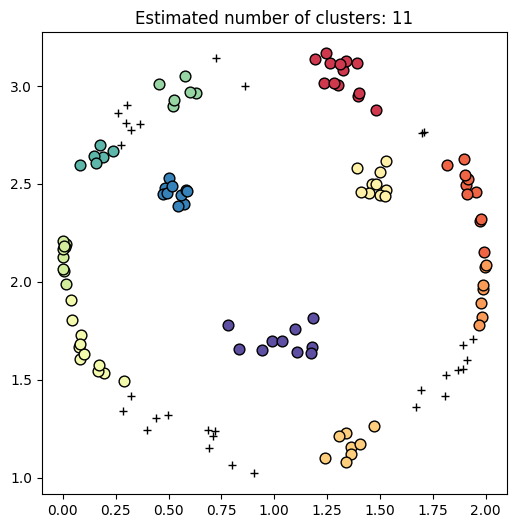

In [30]:
# #############################################################################

op = OPTICS(xi=0.05, min_cluster_size=.05).fit(X)

labels = op.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print('Estimated number of clusters: %d' % n_clusters_)
print('Estimated number of noise points: %d' % n_noise_)

# Black removed and is used for noise instead.
unique_labels = np.unique(labels)

colors = [plt.cm.Spectral(each)
          for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(6,6))

for klass, color in zip(unique_labels[1:], colors[1:]):

    Xk = X[op.labels_ == klass]
    plt.scatter(Xk[:, 0], Xk[:, 1], 60, np.array([color,]),\
                'o', edgecolors='k',linewidths=1, )#, ls = 'None')
    
plt.plot(X[op.labels_ == -1, 0], X[op.labels_ == -1, 1], 'k+', ls = 'None')

plt.title('Estimated number of clusters: %d' % n_clusters_)
plt.show()

Changing the parameter xi will change the estimate:

Estimated number of clusters: 10
Estimated number of noise points: 42


C:\Users\Simon Seo\AppData\Local\Temp\ipykernel_30552\3563464818.py:25: MatplotlibDeprecationWarning: Passing the marker parameter of scatter() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.scatter(Xk[:, 0], Xk[:, 1], 60, np.array([color,]),\


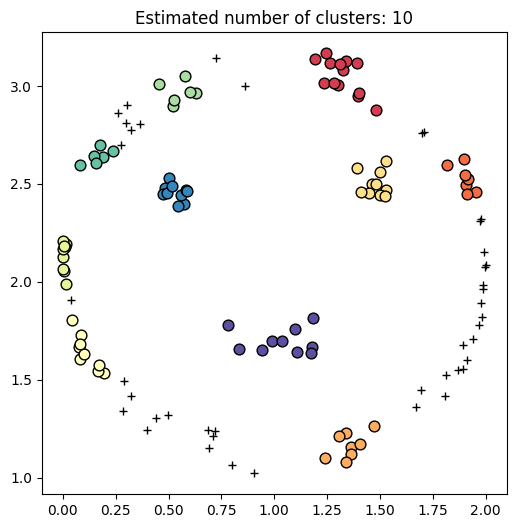

In [31]:
# #############################################################################

op = OPTICS(xi=0.2, min_cluster_size=.05).fit(X)

labels = op.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print('Estimated number of clusters: %d' % n_clusters_)
print('Estimated number of noise points: %d' % n_noise_)

# Black removed and is used for noise instead.
unique_labels = np.unique(labels)

colors = [plt.cm.Spectral(each)
          for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(6,6))

for klass, color in zip(unique_labels[1:], colors[1:]):

    Xk = X[op.labels_ == klass]
    plt.scatter(Xk[:, 0], Xk[:, 1], 60, np.array([color,]),\
                'o', edgecolors='k',linewidths=1, )#, ls = 'None')
    
plt.plot(X[op.labels_ == -1, 0], X[op.labels_ == -1, 1], 'k+', ls = 'None')

plt.title('Estimated number of clusters: %d' % n_clusters_)
plt.show()

My final note here is that building and evaluating clustering schemes is tricky. For our clustering to make sense, we need to have a good knowledge of the structure of our data, but unfortunately, this is often what we'd like to learn by building the clustering in first place. I don't have a lot of wisdom to share; just this word of caution.

### Finally, we will take a look at how to use a probabilistic model: Gaussian Mixture Models.

Again from sklearn docs: A Gaussian mixture model is a probabilistic model that assumes all the data points are generated from a mixture of a finite number of Gaussian distributions with unknown parameters. One can think of mixture models as generalizing k-means clustering to incorporate information about the covariance structure of the data as well as the centers of the latent Gaussians.

In [32]:
from sklearn import mixture
from matplotlib.patches import Ellipse

In [33]:
#Function from https://jakevdp.github.io/PythonDataScienceHandbook/06.00-figure-code.html#Covariance-Type

def draw_ellipse(gmm, ax, **kwargs):
    """Draw an ellipse with a given position and covariance"""
    for n in range(gmm.n_components):
        if gmm.covariance_type == 'full':
            covariances = gmm.covariances_[n]
        elif gmm.covariance_type == 'tied':
            covariances = gmm.covariances_
        elif gmm.covariance_type == 'diag':
            covariances = np.diag(gmm.covariances_[n])
        elif gmm.covariance_type == 'spherical':
            covariances = np.eye(gmm.means_.shape[1]) * gmm.covariances_[n]
        v, w = np.linalg.eigh(covariances)
        u = w[0] / np.linalg.norm(w[0])
        angle = np.arctan2(u[1], u[0])
        angle = 180 * angle / np.pi  # convert to degrees
        v = 2. * np.sqrt(2.) * np.sqrt(v)
        
        # Draw the Ellipse
        for nsig in range(1, 4): #1, 2, and 3 sigma
            print(gmm.means_[n], nsig *v[0], nsig *v[1], angle)
            ell = Ellipse(gmm.means_[n], nsig *v[0], nsig *v[1], angle, **kwargs)
            ax.add_patch(ell)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


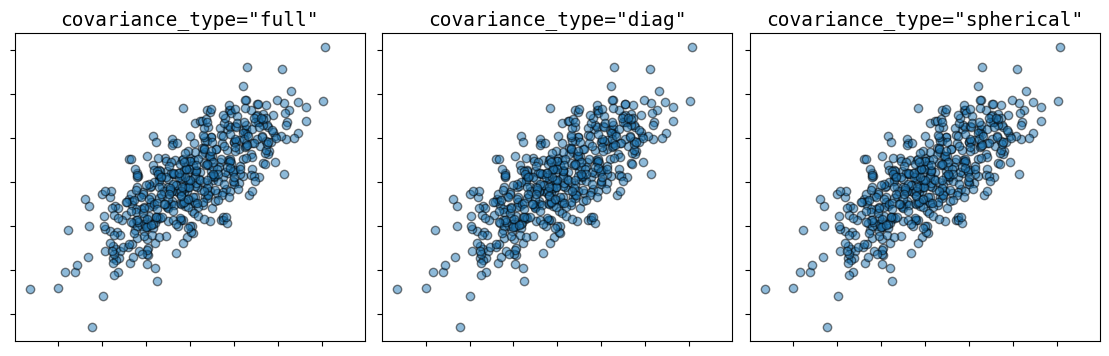

In [34]:
#Figure also adapted from https://jakevdp.github.io/PythonDataScienceHandbook/06.00-figure-code.html#Covariance-Type
 
fig, ax = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.subplots_adjust(wspace=0.05)

rng = np.random.RandomState(20)
Xe = np.dot(rng.randn(500, 2), rng.randn(2, 2))

for i, cov_type in enumerate(['full','diag', 'spherical']):
    model = mixture.GaussianMixture(n_components=1, covariance_type=cov_type).fit(Xe)
    ax[i].axis('equal')
    ax[i].scatter(Xe[:, 0], Xe[:, 1], edgecolor='k', alpha=0.5)
    ax[i].set_title('covariance_type="{0}"'.format(cov_type), size=14, family='monospace')
#    draw_ellipse(gmm=model, ax=ax[i], alpha=0.1, edgecolor='k', facecolor='#808080') # can't get this to work
    ax[i].xaxis.set_major_formatter(plt.NullFormatter())
    ax[i].yaxis.set_major_formatter(plt.NullFormatter())
    ax[i].set_xlim(-5, 5)
    

### Modeling with a Gaussian Mixture Model predicts probabilities.

In [35]:
model = mixture.GaussianMixture(n_components=3, covariance_type='full',random_state=30) 

model.fit(Xb)

y_GMM = model.predict(Xb)

probs = model.predict_proba(Xb)

size = 50 * probs.max(axis=1)**4

In [36]:
y_GMM # This should be 0,1,2 for the colors to work; otherwise, you may have to change the random state

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0,
       2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

### GMM decision function for a "full" covariance:

(-0.5, 2.5)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


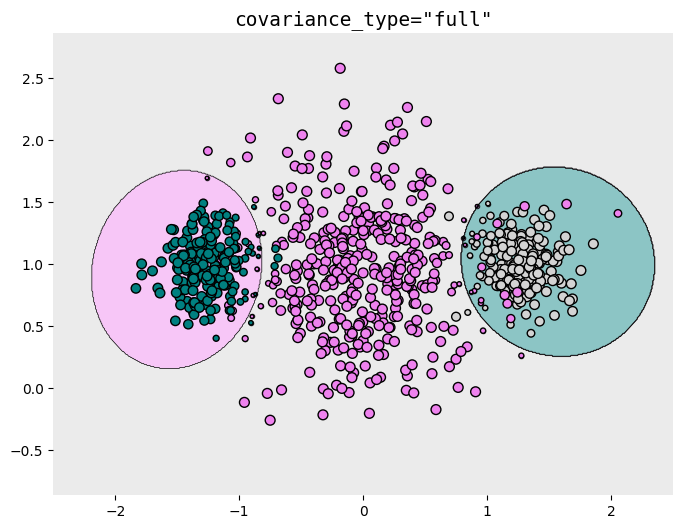

In [37]:
model = mixture.GaussianMixture(n_components=3, covariance_type='full',random_state=41)

model.fit(Xb)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

plt.axis('equal')

plot_decision_regions(Xb, yb.astype(int), 
        clf=model, legend=0, markers = '...', colors = 'lightgray,violet,teal')

plt.scatter(X1b[:,0],X1b[:,1], s = size[:len(y1b)], c = 'lightgray',edgecolors='k')

plt.scatter(X2b[:,0],X2b[:,1], s = size[len(y1b):len(y1b)+len(y2b)], c = 'violet', edgecolors='k')

plt.scatter(X3b[:,0],X3b[:,1],s = size[len(y1b)+len(y2b):], c = 'teal', edgecolors='k')

ax.set_title('covariance_type="{0}"'.format('full'), size=14, family='monospace')

ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-0.5,2.5)

#plt.savefig('GMM_blobs_full.pdf', dpi = 300)

### Now, for comparison, with a spherical covariance:

(-0.5, 2.5)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


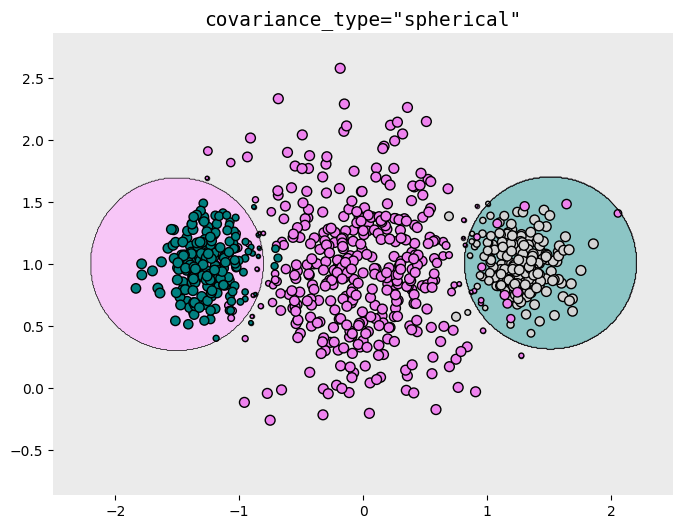

In [38]:
model = mixture.GaussianMixture(n_components=3, covariance_type='spherical',random_state=41)

model.fit(Xb)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

plt.axis('equal')

plot_decision_regions(Xb, yb.astype(int), 
        clf=model, legend=0, markers = '...', colors = 'lightgray,violet,teal')

plt.scatter(X1b[:,0],X1b[:,1], s = size[:len(y1b)], c = 'lightgray',edgecolors='k')

plt.scatter(X2b[:,0],X2b[:,1], s = size[len(y1b):len(y1b)+len(y2b)], c = 'violet', edgecolors='k')

plt.scatter(X3b[:,0],X3b[:,1],s = size[len(y1b)+len(y2b):], c = 'teal', edgecolors='k')

ax.set_title('covariance_type="{0}"'.format('spherical'), size=14, family='monospace')

ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-0.5,2.5)

#plt.savefig('GMM_blobs_spherical.pdf', dpi = 300)

### Finally, we can apply GMMs to the smiley face problem.

We start with 4 components (not expecting, of course, that it would work).

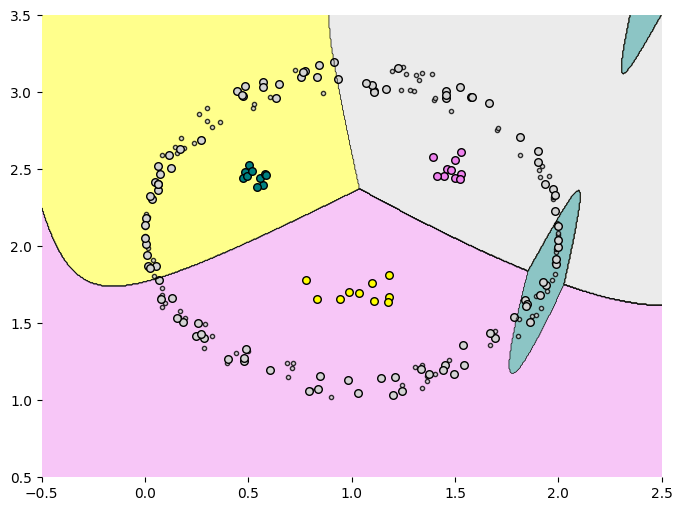

In [39]:
gmm4 = mixture.GaussianMixture(n_components=4, covariance_type='full', random_state=1)

gmm4.fit(X)

plt.figure(figsize=(8,6))

xy = [point(1,2,1) for _ in range(100)]

plot_decision_regions(X, y.astype(int), 
        clf=gmm4, legend=0, markers = '.', colors = 'lightgray,yellow,teal,violet')

plt.scatter(*zip(*xy), s = 30, c = 'lightgray', edgecolors='k')
plt.scatter(X1[:,0],X1[:,1], s = 30, c = 'teal',edgecolors='k')
plt.scatter(X2[:,0],X2[:,1], s = 30, c = 'violet', edgecolors='k')
plt.scatter(X3_stretch.T[:,0]-1.9,X3_stretch.T[:,1],s = 30, c = 'yellow', edgecolors='k')


plt.xlim(-0.5,2.5);

plt.ylim(0.5,3.5);

#plt.savefig('GMMbad.pdf', dpi = 300)

### We can use the BIC criterion to figure out how many Gaussian mixture components best fit the smiley face in the GMM model.

Note that results tend to vary slightly between different runs; in the book we show a run for 10 components, but obtaining 9 or 11 (or even a second minimum at 13) is not uncommon!

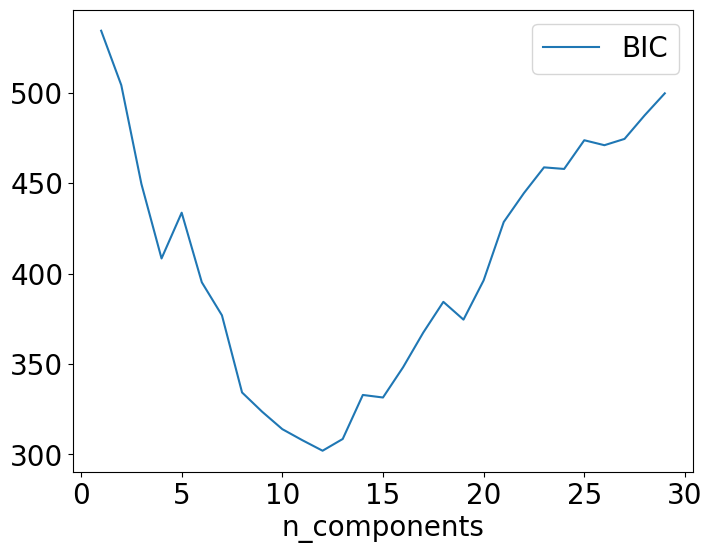

In [40]:
n_components = np.arange(1, 30)

models = [mixture.GaussianMixture(n, covariance_type='full', random_state=0).fit(X)
          for n in n_components]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.plot(n_components, [m.bic(X) for m in models], label='BIC')
ax.legend(loc='best', fontsize=20)
ax.set_xlabel('n_components', fontsize=20);
ax.tick_params(axis='both', which='both', labelsize=20);
#plt.savefig('GMM_smiley_BIC.pdf', dpi = 300)

### And re-do the plot with the appropriate number of components.

In [41]:
#These two functions (note that "draw_ellipse" is not the same as before!) are also from Jake Vanderplas' notebooks.

def draw_ellipse(position, covariance, ax=None, **kwargs):
    """Draw an ellipse with a given position and covariance"""
    ax = ax or plt.gca()
    
    # Convert covariance to principal axes
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0.0
        width, height = 2 * np.sqrt(covariance)
    
    # Draw the Ellipse
 #   for nsig in range(1, 4):
  #      ax.add_patch(Ellipse(position, nsig * width, nsig * height, angle, **kwargs))

def plot_gmm(gmm, X, label=True, ax=None):
    ax = ax or plt.gca()
    labels = gmm.fit(X).predict(X)
    if label:
        ax.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='Accent', zorder=2, edgecolor='k')
    else:
        ax.scatter(X[:, 0], X[:, 1], s=40, zorder=2, edgecolor='k')
    ax.axis('equal')
    
    w_factor = 0.2 / gmm.weights_.max()
    
 #   for pos, covar, w in zip(gmm.means_, gmm.covariances_, gmm.weights_):
        #draw_ellipse(pos, covar, facecolor='#808080', edgecolor='k', alpha=w * w_factor)
        
    ax.tick_params(axis='both', which='both', labelsize=20);

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


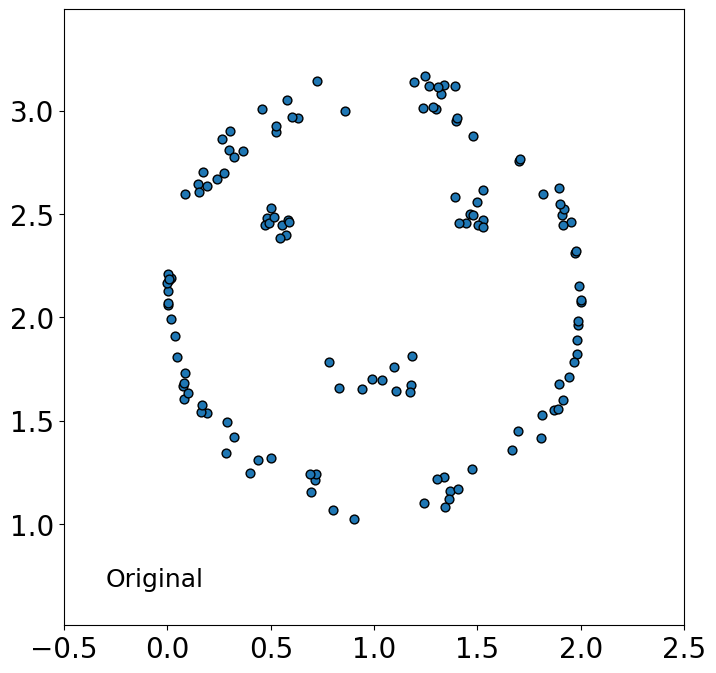

In [42]:
gmm10 = mixture.GaussianMixture(n_components=10, covariance_type='full', random_state=0)

fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(111, aspect='equal')

plot_gmm(gmm10, X, label=False, ax=ax)

plt.xlim(-0.5,2.5);

plt.ylim(0.5,3.5);

plt.text(-0.3,0.7,'Original', fontsize = 18)

ax.tick_params(axis='both', which='both', labelsize=20);

#plt.savefig('Smiley_GMM_10.pdf', dpi = 300)


### Finally, we can use our GMM with 10 components as a generative model to generate new samples that follow the smiley face distribution!

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Text(-0.3, 0.7, 'Generated')

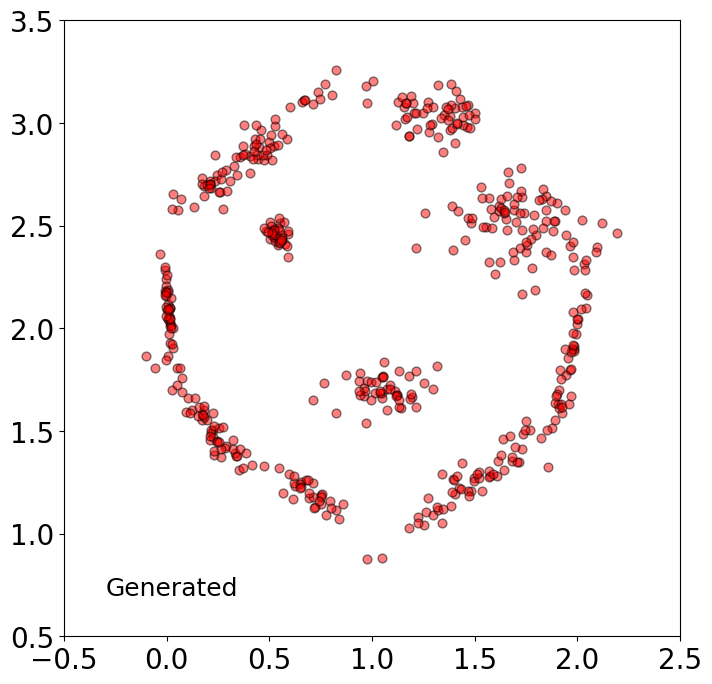

In [43]:
Xnew = gmm10.sample(n_samples=500) #This is how we generate new samples!

fig = plt.figure(figsize=(8, 8))

ax2 = fig.add_subplot(111, aspect='equal', sharey = ax)

ax2.scatter(Xnew[0][:, 0], Xnew[0][:, 1], s = 40, facecolor='r', edgecolor='k', alpha=0.5);

ax2.tick_params(axis='both', which='both', labelsize=20);

plt.xlim(-0.5,2.5);

plt.ylim(0.5,3.5);

plt.text(-0.3,0.7,'Generated', fontsize = 18)

#plt.savefig('Smiley_GMM_generated.pdf', dpi = 300)